In [46]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import polars as pl
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
from functools import partial
from global_land_mask import globe

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from src.loading import (
    load_dyamond_feature_stats,
    load_gpm_feature_stats
)
from src.plotting import (
    discrete_cmap,
    source_line_params
)
from src.saving import (
    save_figure
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define map function

In [30]:
def _make_map(
    df: pl.DataFrame,
    data_to_bin=None,
    lat_coord="centroid_lat",
    lon_coord="centroid_lon",
    dx=5,
    statistic="count",
    normalize=False,
    norm=colors.Normalize(vmin=0.0, vmax=0.25),
    cmap=plt.cm.plasma,
    coastline_color="white",
    extend="max",
    ax=None,
    ticks=None,
    figsize=(6,3),
    return_colorbar_separate=False,
    cbar_kwargs: dict = None,
):
    lat_bins = np.arange(-90, 90 + dx, dx)
    lon_bins = np.arange(-180, 180 + dx, dx)
    lat = df[lat_coord].to_numpy()
    lon = df[lon_coord].to_numpy()
    lon = ((lon + 180) % 360) - 180

    stat = stats.binned_statistic_2d(
        x=lon,
        y=lat,
        values=data_to_bin,
        statistic=statistic,
        bins=[lon_bins, lat_bins],
    ).statistic

    # binned_statistic_2d returns [x_bin, y_bin]
    # pcolormesh wants [y, x]
    data = stat.T

    if normalize:
        data = 100 * data / np.nansum(data)

    if ax is None:
        fig, ax = plt.subplots(
            figsize=figsize,
            subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)},
        )
        ax.set_aspect('auto')
    else:
        fig = ax.get_figure()

    im = ax.pcolormesh(
        lon_bins,
        lat_bins,
        data,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )

    # Build colorbar kwargs: defaults first, then user overrides.
    cbar_kwargs = {} if cbar_kwargs is None else dict(cbar_kwargs)

    if return_colorbar_separate:
        orientation = cbar_kwargs.get("orientation", "horizontal")
        default_cbar_figsize = (6, 0.4) if orientation == "horizontal" else (0.4, 3)
        cbar_figsize = cbar_kwargs.pop("cbar_figsize", default_cbar_figsize)

        cbar_defaults = {"orientation": "horizontal", "extend": extend}
        cbar_defaults.update(cbar_kwargs)

        cbar_fig, cbar_ax = plt.subplots(figsize=cbar_figsize)
        cb = cbar_fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            cax=cbar_ax,
            **cbar_defaults,
        )
        if cbar_defaults["orientation"] == "horizontal":
            cbar_fig.subplots_adjust(left=0.05, right=0.95, bottom=0.5, top=0.9)
        else:
            cbar_fig.subplots_adjust(left=0.1, right=0.5, bottom=0.05, top=0.95)

        if ticks is not None:
            if cbar_defaults["orientation"] == "horizontal":
                cb.ax.set_xticks(ticks)
            else:
                cb.ax.set_yticks(ticks)
    else:
        cbar_defaults = {
            "orientation": "horizontal",
            "aspect": 40,
            "pad": 0.15,
            "extend": extend,
        }
        cbar_defaults.update(cbar_kwargs)
        cb = fig.colorbar(im, **cbar_defaults)

        if ticks is not None:
            if cbar_defaults["orientation"] == "horizontal":
                cb.ax.set_xticks(ticks)
            else:
                cb.ax.set_yticks(ticks)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        xlocs=[-160, -90, 0, 90, 160],
        ylocs=np.arange(-60, 60, 15),
        linewidth=1,
        linestyle="dotted",
        color="darkgrey",
        alpha=1,
    )
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.right_labels = True
    gl.top_labels = False

    ax.coastlines(color=coastline_color, linewidth=0.75)

    EPS = 1e-6
    ax.set_extent([-180 + EPS, 180 - EPS, -22, 22], crs=ccrs.PlateCarree())

    if return_colorbar_separate:
        return fig, ax, cbar_fig, cbar_ax, data
    return fig, ax, data

# Make Maps

## All Features

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_SCREAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_SHiELD.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapPFs_MPAS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphol

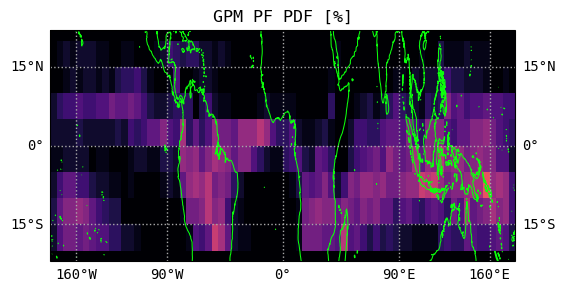

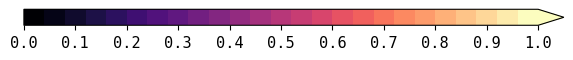

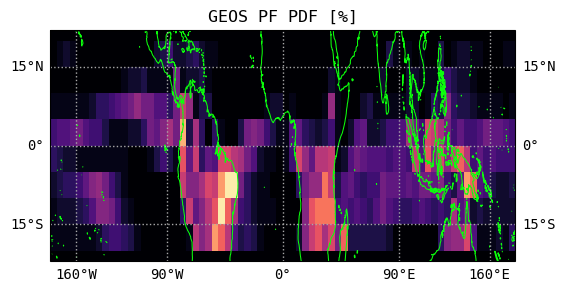

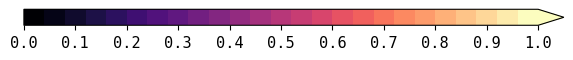

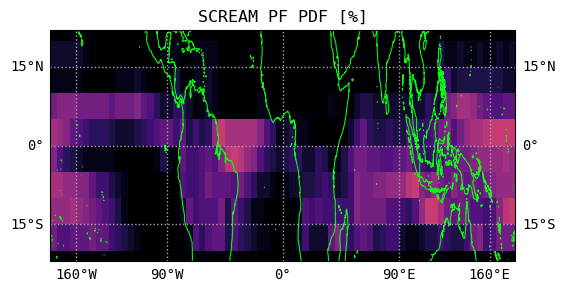

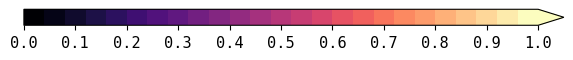

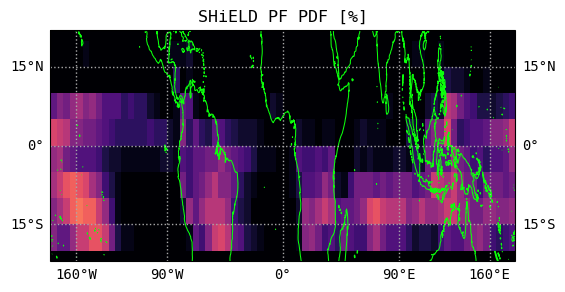

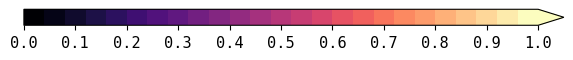

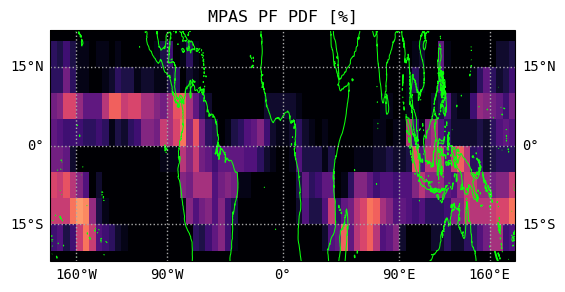

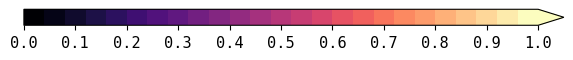

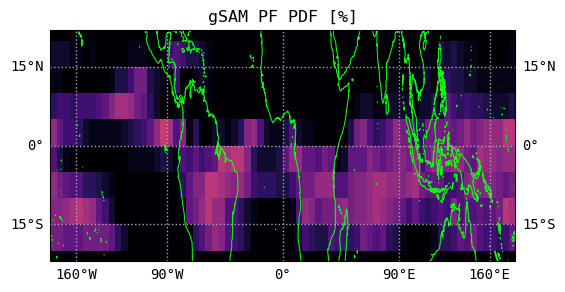

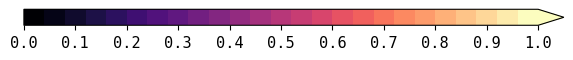

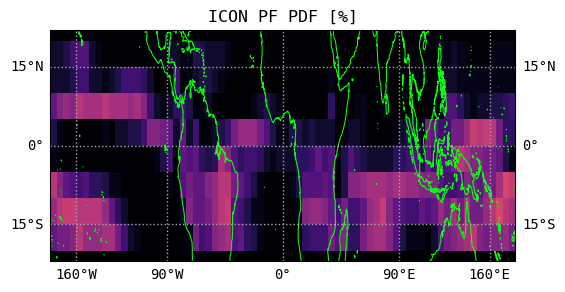

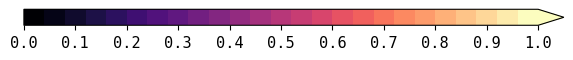

In [39]:
_RES = "0p05"
_ACCUM = "15min"
_EDGE_FRAC_MAX = 0.05
_MAX_PR_MIN = 10.0

feature_stats_dict = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
}

for source, df in feature_stats_dict.items():
    fig, ax, cbar_fig, cbar_ax, data = _make_map(
        df,
        normalize=True,
        cmap=discrete_cmap('magma', N=25, under_color='White'),
        norm=colors.Normalize(vmin=0.0, vmax=1),
        coastline_color='xkcd:neon green',
        ticks=np.arange(0, 1+0.1, 0.1),
        return_colorbar_separate=True,
        figsize=(6,3)
    )
    ax.set_title(f'{source} PF PDF [%]', fontsize=12)
    save_figure(fig, f'MapPFs_{source}.pdf')
    save_figure(cbar_fig, f'MapPFs_colorbar.pdf')

## Extreme Features

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GEOS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SCREAM.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_MPAS.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamo

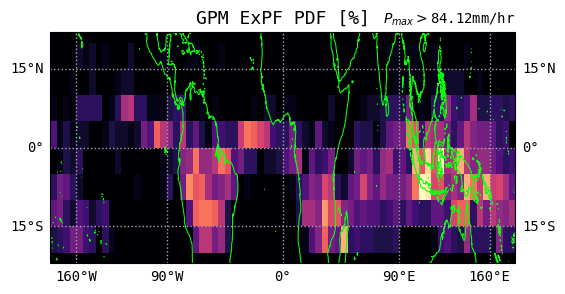

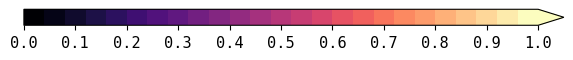

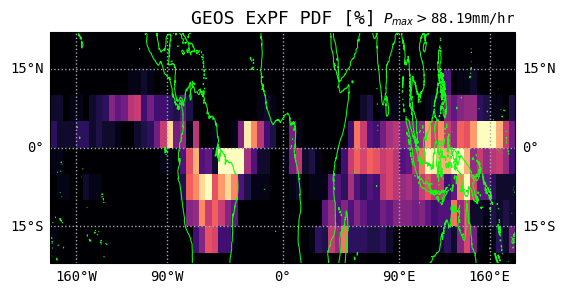

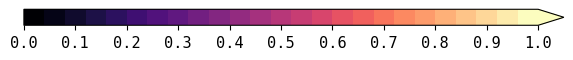

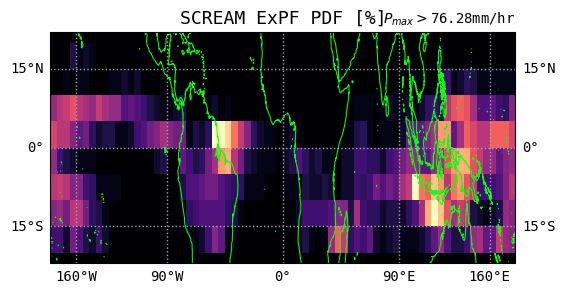

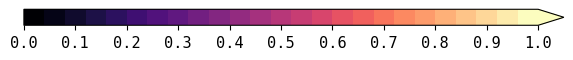

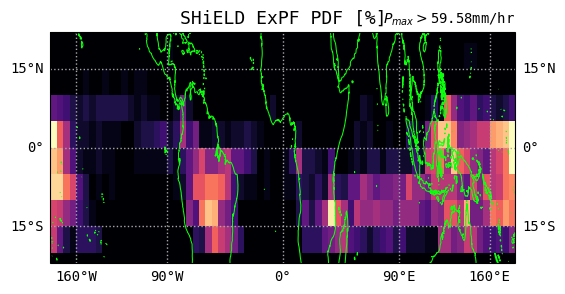

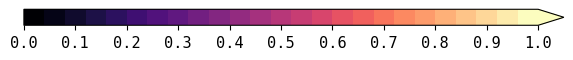

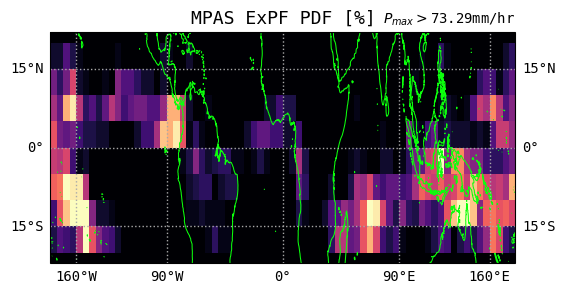

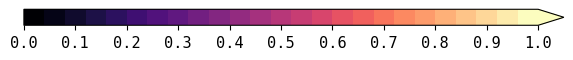

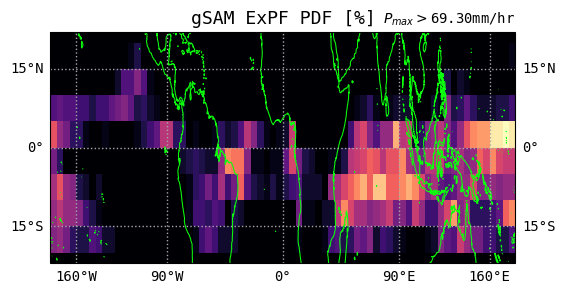

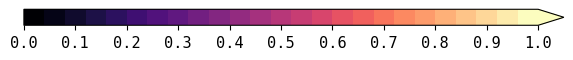

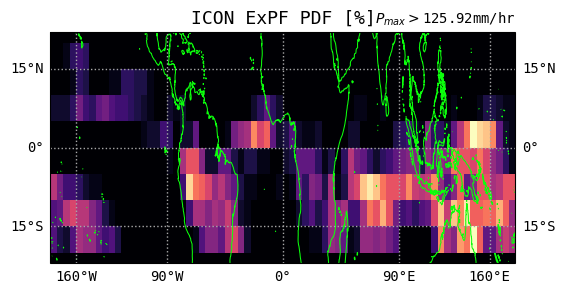

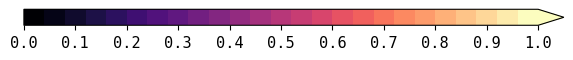

In [40]:
_RES = "0p05"
_ACCUM = "15min"
_EDGE_FRAC_MAX = 0.05
_MAX_PR_MIN = 10.0

feature_stats_dict = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
}

for source, df in feature_stats_dict.items():

    thresh = df['max_precip_mm_hr'].quantile(0.95)

    df = df.filter(
        pl.col("max_precip_mm_hr")>= thresh
    )

    fig, ax, cbar_fig, cbar_ax, data = _make_map(
        df,
        normalize=True,
        cmap=discrete_cmap('magma', N=25, under_color='White'),
        norm=colors.Normalize(vmin=0.0, vmax=1),
        coastline_color='xkcd:neon green',
        ticks=np.arange(0, 1+0.1, 0.1),
        return_colorbar_separate=True,
        figsize=(6,3)
    )
    ax.set_title(f'{source} ExPF PDF [%]')
    ax.set_title('$P_{max}>$' +f'{thresh:.2f}mm/hr', loc='right', fontsize=10)

    save_figure(fig, f'MapExPFs_{source}.pdf')
    save_figure(cbar_fig, f'MapExPFs_colorbar.pdf')

# Land-Ocean Contrast

In [ ]:
_RES = "0p05"
_ACCUM = "15min"
_EDGE_FRAC_MAX = 0.05
_MAX_PR_MIN = 10.0

feature_stats_dict = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
}



Domain -20.0 to 20.0 deg: land 23.7%, ocean 76.3%

    GPM: all +0.40   extreme +0.90   (n=62,059 / 3,104, thresh=84.1 mm/hr)
   GEOS: all +1.47   extreme +0.91   (n=321,979 / 16,100, thresh=88.2 mm/hr)
   gSAM: all +0.11   extreme -0.86   (n=309,108 / 15,456, thresh=69.3 mm/hr)
   ICON: all +0.14   extreme +0.19   (n=628,422 / 31,422, thresh=125.9 mm/hr)
   MPAS: all +0.44   extreme -0.84   (n=217,015 / 10,852, thresh=73.3 mm/hr)
 SCREAM: all -0.46   extreme -0.28   (n=636,968 / 31,849, thresh=76.3 mm/hr)
 SHiELD: all +0.34   extreme +0.45   (n=233,398 / 11,671, thresh=59.6 mm/hr)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/LandOcean_PF_ExPF_Occurrence.pdf as PDF ...


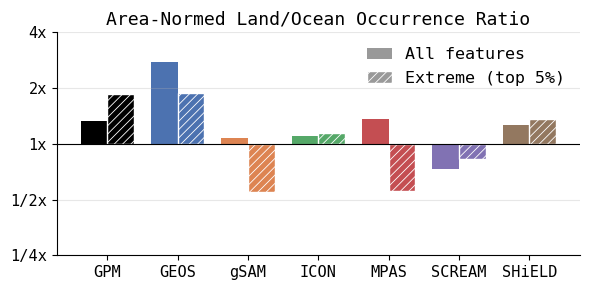

In [64]:
# ============================================================
# THE QUANTITY BEING COMPARED OVER LAND VS OCEAN
# Set to None to count features (occurrence frequency).
# Set to a column name to sum that column instead
# (e.g. "precip_volume_m3", "total_precip_mm_hr", "area_km2").
WEIGHT_COL = None
# ============================================================

EXTREME_Q = 0.95

# --- cosine-weighted land/ocean area fractions of the domain ---
lat_min = min(df["centroid_lat"].min() for df in feature_stats_dict.values())
lat_max = max(df["centroid_lat"].max() for df in feature_stats_dict.values())

_lat = np.arange(lat_min + 0.125, lat_max, 0.25)
_lon = np.arange(-179.875, 180, 0.25)
_LON, _LAT = np.meshgrid(_lon, _lat)
_w = np.cos(np.deg2rad(_LAT))
f_land = float((_w * globe.is_land(_LAT, _LON)).sum() / _w.sum())
f_ocean = 1.0 - f_land
print(f"Domain {lat_min:.1f} to {lat_max:.1f} deg: land {f_land:.1%}, ocean {f_ocean:.1%}\n")

# --- per-source land/ocean contrast ---
sources, contrast_all, contrast_ext = [], [], []

for source, df in feature_stats_dict.items():
    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out in ((df, contrast_all), (df_ext, contrast_ext)):
        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        # weight per feature: 1 for occurrence, or the column value
        wt = np.ones(len(on_land)) if WEIGHT_COL is None else df_sub[WEIGHT_COL].to_numpy()

        land_total = wt[on_land].sum()
        ocean_total = wt[~on_land].sum()
        out.append(np.log2((land_total / f_land) / (ocean_total / f_ocean)))

    sources.append(source)
    print(f"{source:>7}: all {contrast_all[-1]:+.2f}   extreme {contrast_ext[-1]:+.2f}"
          f"   (n={df.height:,} / {df_ext.height:,}, thresh={thresh:.1f} mm/hr)")

# --- grouped bar chart ---
colors = [source_line_params(s)['color'] for s in sources]
x = np.arange(len(sources))
w = 0.38
label = "Occurrence" if WEIGHT_COL is None else WEIGHT_COL

plt.rcParams['hatch.linewidth'] = 0.6  # thinner white stripes

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x - w/2, contrast_all, w, color=colors)
ax.bar(x + w/2, contrast_ext, w, color=colors, hatch="////", edgecolor="white")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, sources)
ax.set_yticks([-2, -1, 0, 1, 2], ["1/4x", "1/2x", "1x", "2x", "4x"])
ax.set_title(f"Area-Normed Land/Ocean Occurrence Ratio")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# legend for the fill pattern only, since color now encodes source
handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////", edgecolor="white")]
ax.legend(handles, ["All features", f"Extreme (top {100*(1-EXTREME_Q):.0f}%)"], frameon=False)

fig.tight_layout()
save_figure(fig, 'LandOcean_PF_ExPF_Occurrence.pdf')

Domain -20.0 to 20.0 deg: land 23.7%, ocean 76.3%

    GPM: all +0.53   extreme +0.59   (n=62,059 / 3,104, thresh=84.1 mm/hr)
   GEOS: all +1.31   extreme +0.75   (n=321,979 / 16,100, thresh=88.2 mm/hr)
   gSAM: all -0.09   extreme -0.64   (n=309,108 / 15,456, thresh=69.3 mm/hr)
   ICON: all +0.18   extreme -0.01   (n=628,422 / 31,422, thresh=125.9 mm/hr)
   MPAS: all -0.20   extreme -0.90   (n=217,015 / 10,852, thresh=73.3 mm/hr)
 SCREAM: all -0.08   extreme +0.12   (n=636,968 / 31,849, thresh=76.3 mm/hr)
 SHiELD: all +0.29   extreme +0.35   (n=233,398 / 11,671, thresh=59.6 mm/hr)
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/LandOcean_PF_ExPF_TotalPrecip.pdf as PDF ...


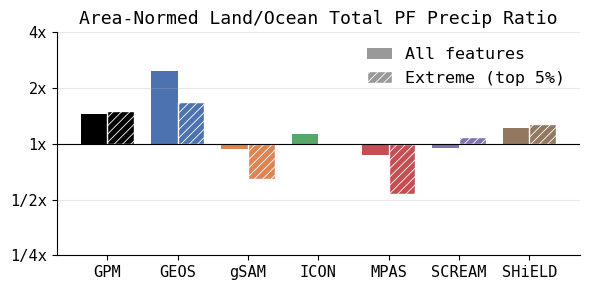

In [65]:
# ============================================================
# THE QUANTITY BEING COMPARED OVER LAND VS OCEAN
# Set to None to count features (occurrence frequency).
# Set to a column name to sum that column instead
# (e.g. "precip_volume_m3", "total_precip_mm_hr", "area_km2").
WEIGHT_COL = "total_precip_mm_hr_km2"
# ============================================================

EXTREME_Q = 0.95

# --- cosine-weighted land/ocean area fractions of the domain ---
lat_min = min(df["centroid_lat"].min() for df in feature_stats_dict.values())
lat_max = max(df["centroid_lat"].max() for df in feature_stats_dict.values())

_lat = np.arange(lat_min + 0.125, lat_max, 0.25)
_lon = np.arange(-179.875, 180, 0.25)
_LON, _LAT = np.meshgrid(_lon, _lat)
_w = np.cos(np.deg2rad(_LAT))
f_land = float((_w * globe.is_land(_LAT, _LON)).sum() / _w.sum())
f_ocean = 1.0 - f_land
print(f"Domain {lat_min:.1f} to {lat_max:.1f} deg: land {f_land:.1%}, ocean {f_ocean:.1%}\n")

# --- per-source land/ocean contrast ---
sources, contrast_all, contrast_ext = [], [], []

for source, df in feature_stats_dict.items():
    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out in ((df, contrast_all), (df_ext, contrast_ext)):
        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        # weight per feature: 1 for occurrence, or the column value
        wt = np.ones(len(on_land)) if WEIGHT_COL is None else df_sub[WEIGHT_COL].to_numpy()

        land_total = wt[on_land].sum()
        ocean_total = wt[~on_land].sum()
        out.append(np.log2((land_total / f_land) / (ocean_total / f_ocean)))

    sources.append(source)
    print(f"{source:>7}: all {contrast_all[-1]:+.2f}   extreme {contrast_ext[-1]:+.2f}"
          f"   (n={df.height:,} / {df_ext.height:,}, thresh={thresh:.1f} mm/hr)")

# --- grouped bar chart ---
colors = [source_line_params(s)['color'] for s in sources]
x = np.arange(len(sources))
w = 0.38
label = "Total PF Precipitation"

plt.rcParams['hatch.linewidth'] = 0.6  # thinner white stripes

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x - w/2, contrast_all, w, color=colors)
ax.bar(x + w/2, contrast_ext, w, color=colors, hatch="////", edgecolor="white")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, sources)
ax.set_yticks([-2, -1, 0, 1, 2], ["1/4x", "1/2x", "1x", "2x", "4x"])
ax.set_title(f"Area-Normed Land/Ocean Total PF Precip Ratio")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# legend for the fill pattern only, since color now encodes source
handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////", edgecolor="white")]
ax.legend(handles, ["All features", f"Extreme (top {100*(1-EXTREME_Q):.0f}%)"], frameon=False)

fig.tight_layout()
save_figure(fig, 'LandOcean_PF_ExPF_TotalPrecip.pdf')

Domain -20.0 to 20.0 deg: land 23.7%, ocean 76.3%

    GPM: all +0.42   extreme +0.47   (n=62,059 / 3,104, thresh=84.1 mm/hr)
   GEOS: all +1.26   extreme +0.74   (n=321,979 / 16,100, thresh=88.2 mm/hr)
   gSAM: all +0.10   extreme -0.55   (n=309,108 / 15,456, thresh=69.3 mm/hr)
   ICON: all +0.24   extreme -0.12   (n=628,422 / 31,422, thresh=125.9 mm/hr)
   MPAS: all +0.08   extreme -0.88   (n=217,015 / 10,852, thresh=73.3 mm/hr)
 SCREAM: all -0.08   extreme +0.27   (n=636,968 / 31,849, thresh=76.3 mm/hr)
 SHiELD: all +0.19   extreme +0.18   (n=233,398 / 11,671, thresh=59.6 mm/hr)


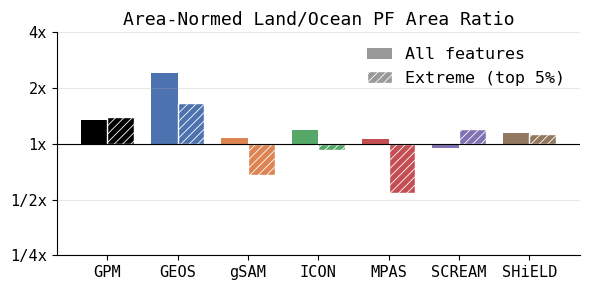

In [66]:
# ============================================================
# THE QUANTITY BEING COMPARED OVER LAND VS OCEAN
# Set to None to count features (occurrence frequency).
# Set to a column name to sum that column instead
# (e.g. "precip_volume_m3", "total_precip_mm_hr", "area_km2").
WEIGHT_COL = "area_km2"
# ============================================================

EXTREME_Q = 0.95

# --- cosine-weighted land/ocean area fractions of the domain ---
lat_min = min(df["centroid_lat"].min() for df in feature_stats_dict.values())
lat_max = max(df["centroid_lat"].max() for df in feature_stats_dict.values())

_lat = np.arange(lat_min + 0.125, lat_max, 0.25)
_lon = np.arange(-179.875, 180, 0.25)
_LON, _LAT = np.meshgrid(_lon, _lat)
_w = np.cos(np.deg2rad(_LAT))
f_land = float((_w * globe.is_land(_LAT, _LON)).sum() / _w.sum())
f_ocean = 1.0 - f_land
print(f"Domain {lat_min:.1f} to {lat_max:.1f} deg: land {f_land:.1%}, ocean {f_ocean:.1%}\n")

# --- per-source land/ocean contrast ---
sources, contrast_all, contrast_ext = [], [], []

for source, df in feature_stats_dict.items():
    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out in ((df, contrast_all), (df_ext, contrast_ext)):
        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        # weight per feature: 1 for occurrence, or the column value
        wt = np.ones(len(on_land)) if WEIGHT_COL is None else df_sub[WEIGHT_COL].to_numpy()

        land_total = wt[on_land].sum()
        ocean_total = wt[~on_land].sum()
        out.append(np.log2((land_total / f_land) / (ocean_total / f_ocean)))

    sources.append(source)
    print(f"{source:>7}: all {contrast_all[-1]:+.2f}   extreme {contrast_ext[-1]:+.2f}"
          f"   (n={df.height:,} / {df_ext.height:,}, thresh={thresh:.1f} mm/hr)")

# --- grouped bar chart ---
colors = [source_line_params(s)['color'] for s in sources]
x = np.arange(len(sources))
w = 0.38
label = "PF Area"

plt.rcParams['hatch.linewidth'] = 0.6  # thinner white stripes

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x - w/2, contrast_all, w, color=colors)
ax.bar(x + w/2, contrast_ext, w, color=colors, hatch="////", edgecolor="white")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, sources)
ax.set_yticks([-2, -1, 0, 1, 2], ["1/4x", "1/2x", "1x", "2x", "4x"])
ax.set_title(f"Area-Normed Land/Ocean PF Area Ratio")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# legend for the fill pattern only, since color now encodes source
handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////", edgecolor="white")]
ax.legend(handles, ["All features", f"Extreme (top {100*(1-EXTREME_Q):.0f}%)"], frameon=False)

fig.tight_layout()


    GPM: all +0.16   extreme +0.09
   GEOS: all +0.12   extreme +0.07
   gSAM: all -0.21   extreme -0.07
   ICON: all -0.06   extreme +0.09
   MPAS: all -0.32   extreme -0.03
 SCREAM: all -0.00   extreme -0.09
 SHiELD: all +0.11   extreme +0.21


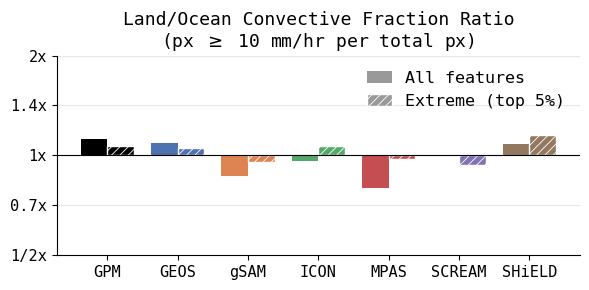

In [67]:
EXTREME_Q = 0.95

# --- per-source land/ocean convective fraction contrast ---
sources, contrast_all, contrast_ext = [], [], []

for source, df in feature_stats_dict.items():
    thresh = df["max_precip_mm_hr"].quantile(EXTREME_Q)
    df_ext = df.filter(pl.col("max_precip_mm_hr") >= thresh)

    for df_sub, out in ((df, contrast_all), (df_ext, contrast_ext)):
        lat = df_sub["centroid_lat"].to_numpy()
        lon = (df_sub["centroid_lon"].to_numpy() + 180.0) % 360.0 - 180.0
        on_land = globe.is_land(lat, lon)

        conv = df_sub["px_ge_10mmhr"].to_numpy()
        tot = df_sub["size_px"].to_numpy()

        # convective fraction, pooled over all features on each side
        cf_land = conv[on_land].sum() / tot[on_land].sum()
        cf_ocean = conv[~on_land].sum() / tot[~on_land].sum()

        out.append(np.log2(cf_land / cf_ocean))

    sources.append(source)
    print(f"{source:>7}: all {contrast_all[-1]:+.2f}   extreme {contrast_ext[-1]:+.2f}")

# --- grouped bar chart ---
colors = [source_line_params(s)['color'] for s in sources]
x = np.arange(len(sources))
w = 0.38

plt.rcParams['hatch.linewidth'] = 0.6

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x - w/2, contrast_all, w, color=colors)
ax.bar(x + w/2, contrast_ext, w, color=colors, hatch="////", edgecolor="white")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, sources)
ax.set_yticks([-1, -0.5, 0, 0.5, 1], ["1/2x", "0.7x", "1x", "1.4x", "2x"])
ax.set_title("Land/Ocean Convective Fraction Ratio\n(px $\\geq$ 10 mm/hr per total px)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor="0.6"),
           plt.Rectangle((0, 0), 1, 1, facecolor="0.6", hatch="////", edgecolor="white")]
ax.legend(handles, ["All features", f"Extreme (top {100*(1-EXTREME_Q):.0f}%)"], frameon=False)

fig.tight_layout()

# Sensitivity Sweeps

## Maps and Edge Frac Max

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_GPM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_GEOS_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_SCREAM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_SHiELD_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensiti

/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_24101/3955006119.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_MPAS_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_gSAM_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_ICON_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/sensitivity/MapPFs_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures

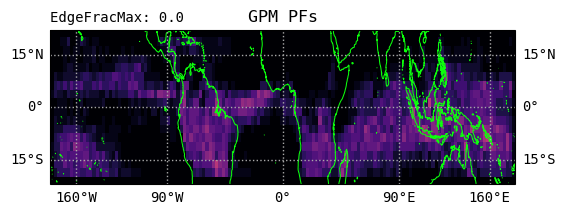

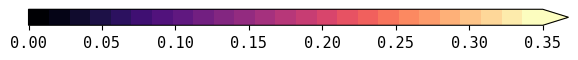

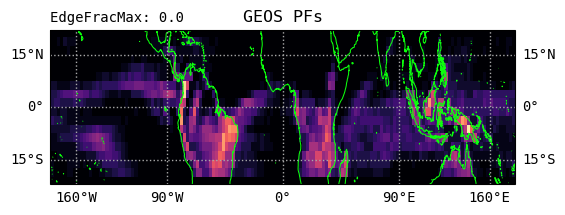

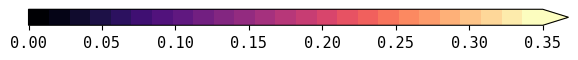

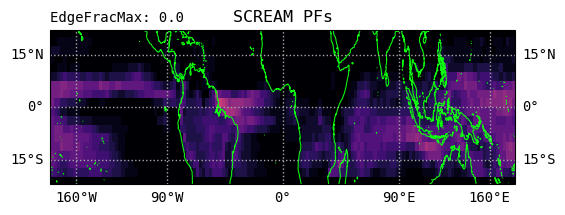

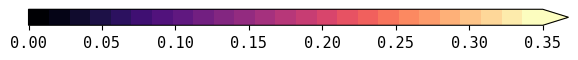

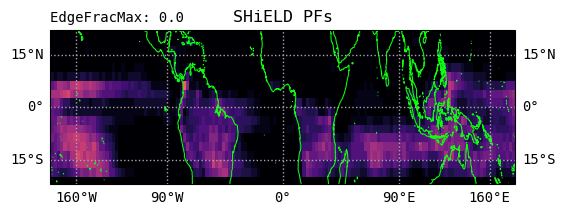

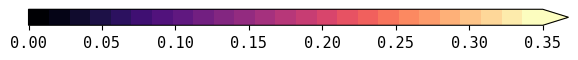

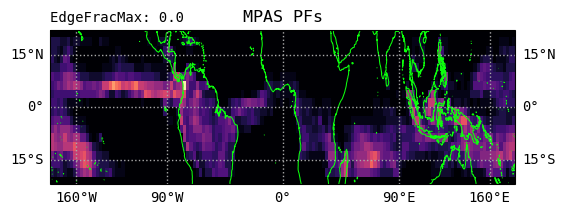

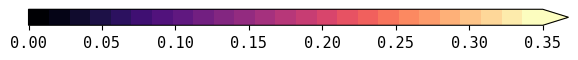

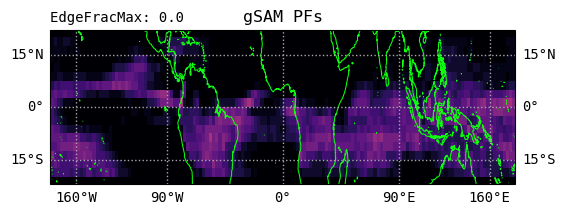

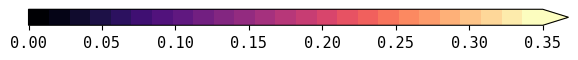

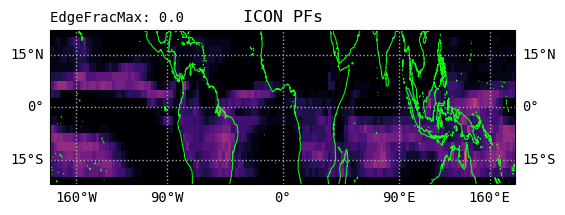

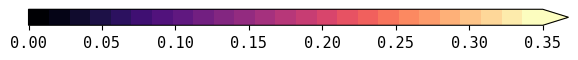

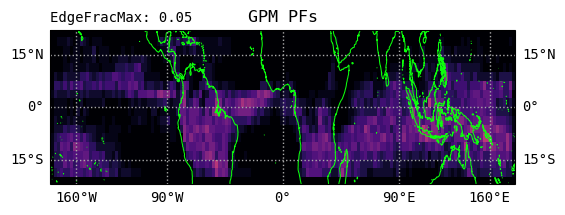

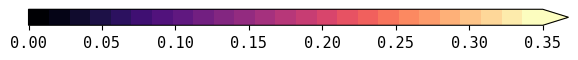

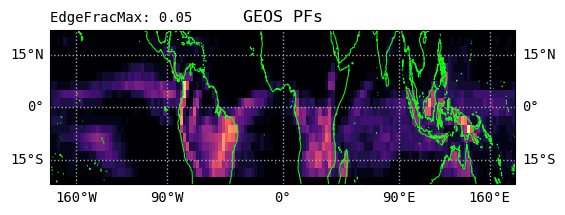

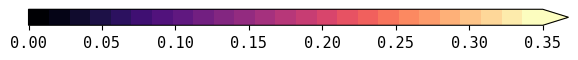

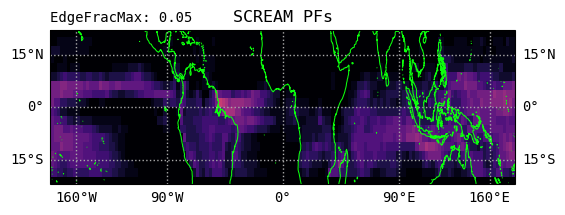

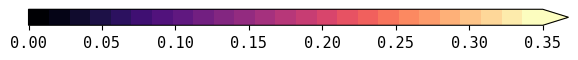

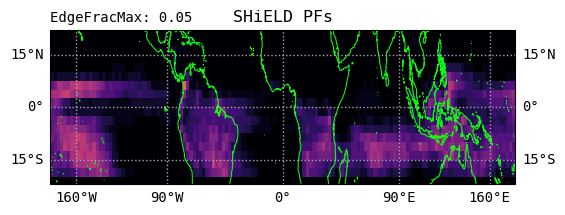

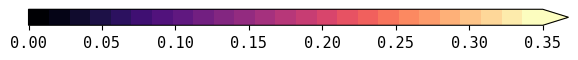

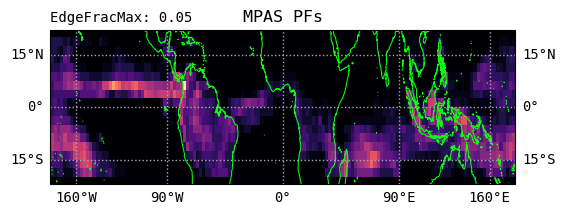

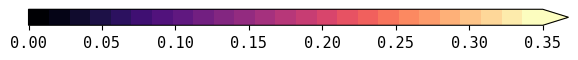

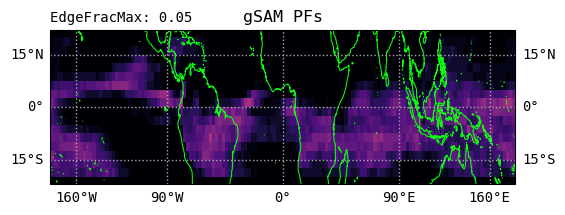

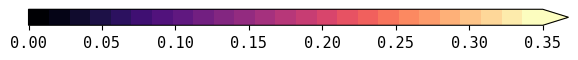

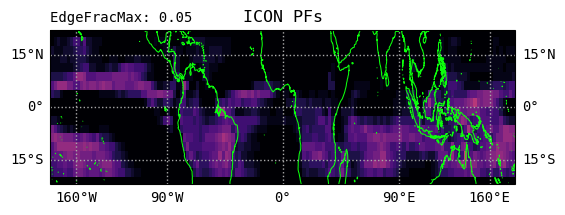

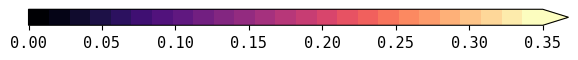

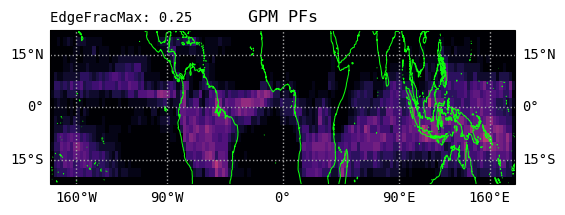

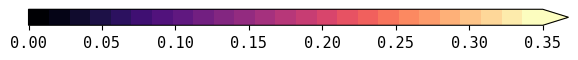

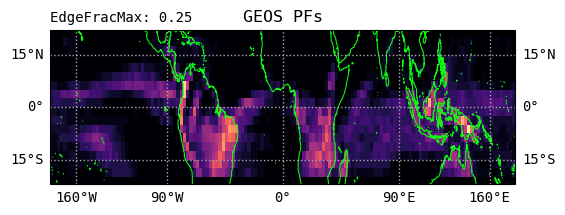

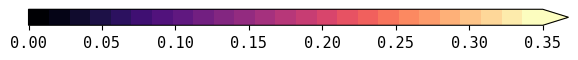

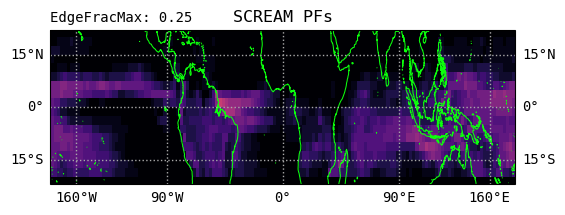

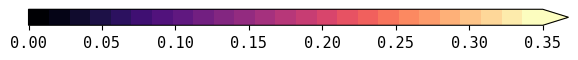

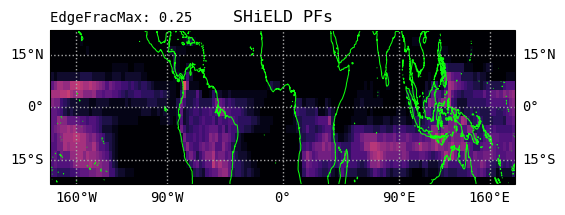

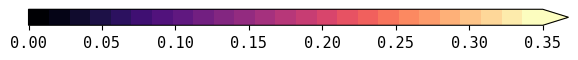

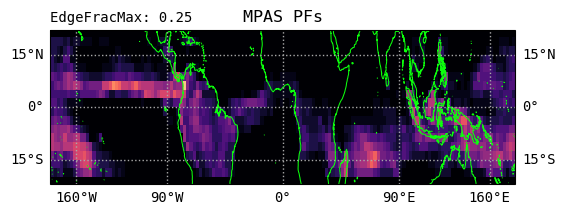

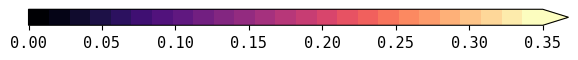

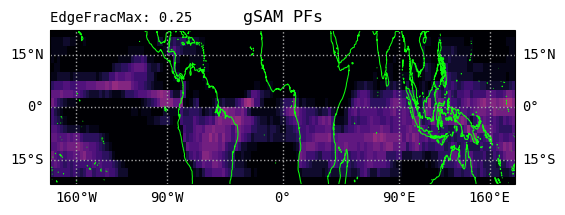

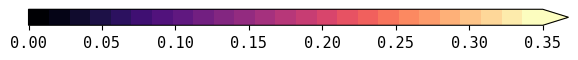

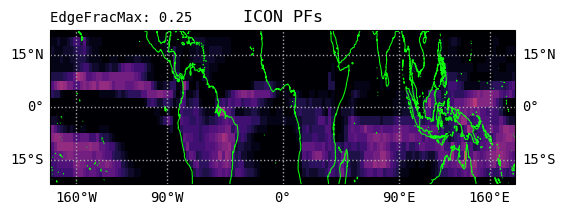

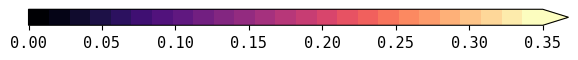

In [ ]:
_RES = "0p05"
_ACCUM = "15min"
edge_frac_max_list = [0.0, 0.05, 0.25]

for _EDGE_FRAC_MAX in edge_frac_max_list:
    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    }

    for source, df in feature_stats_dict.items():
        fig, ax, cbar_fig, cbar_ax, data = _make_map(
            df,
            normalize=True,
            cmap=discrete_cmap('magma', N=25, under_color='White'),
            norm=colors.Normalize(vmin=0.0, vmax=0.35),
            coastline_color='xkcd:neon green',
            ticks=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
            return_colorbar_separate=True,
            figsize=(6,2)
        )
        ax.set_title(f'{source} PFs', fontsize=12)
        ax.set_title(f'EdgeFracMax: {_EDGE_FRAC_MAX}', loc='left', fontsize=10)
        save_figure(fig, f'sensitivity/MapExPFs_{source}_EdgeFracMax{_EDGE_FRAC_MAX}.pdf')
        save_figure(cbar_fig, f'sensitivity/MapExPFs_EdgeFracMax{_EDGE_FRAC_MAX}_colorbar.pdf')

Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GEOS_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GEOS_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SCREAM_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SCREAM_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD_EdgeFracMax0.0.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD_EdgeFracMax0.0_colorbar.pdf as PDF ...
Saving

/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_48134/3955006119.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_SHiELD_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_MPAS_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_MPAS_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_gSAM_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_gSAM_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_ICON_EdgeFracMax0.05.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_ICON_EdgeFracMax0.05_colorbar.pdf as PDF ...
Saving /Users/pedro/Projects/Coding/gpm_dyamond_extreme_morphology/figures/MapExPFs_GPM_EdgeFracMax0.25.pdf as PDF ...
Sav

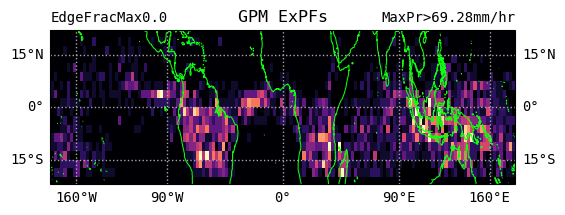

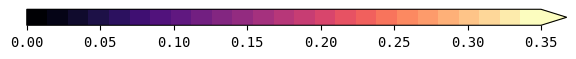

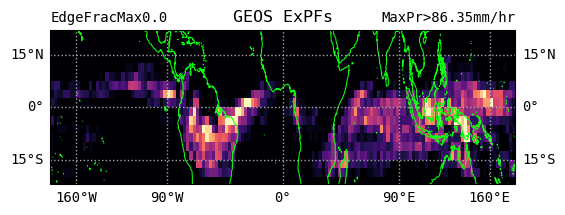

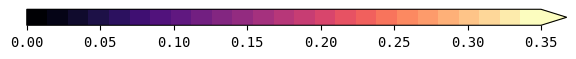

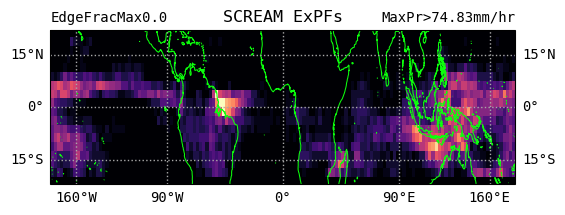

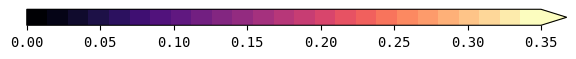

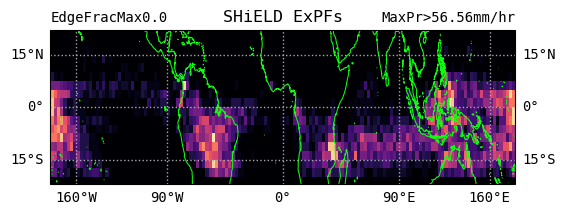

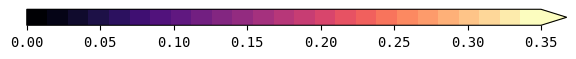

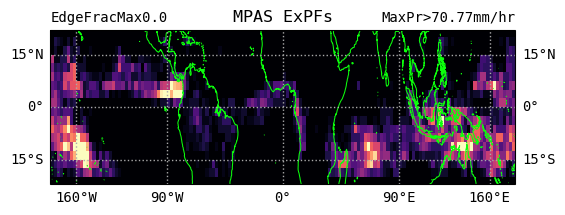

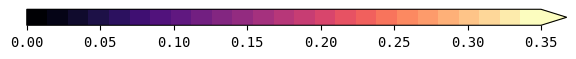

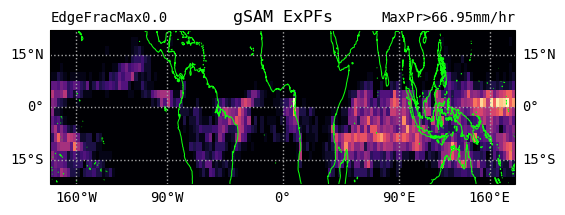

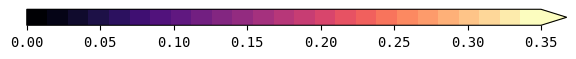

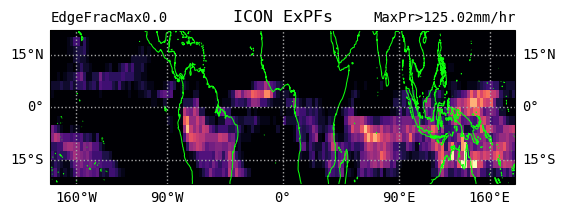

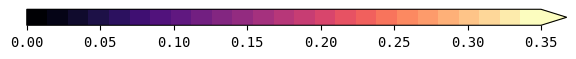

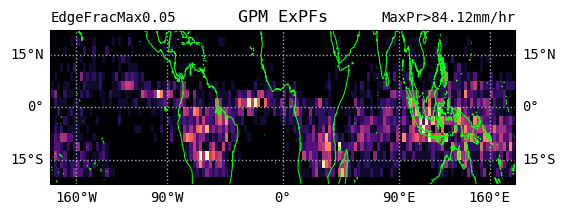

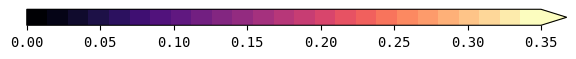

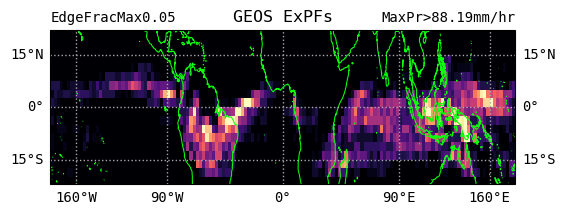

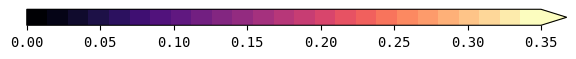

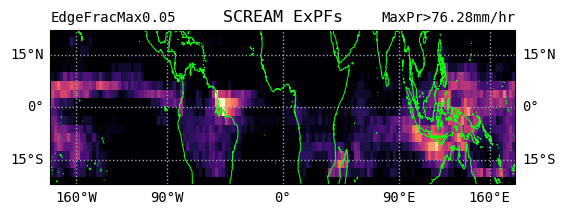

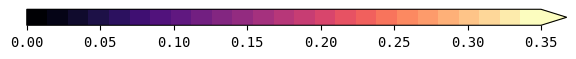

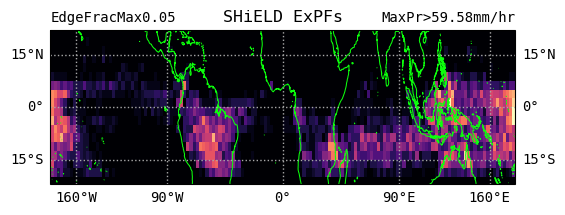

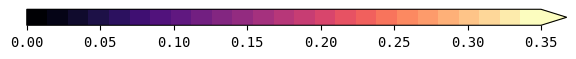

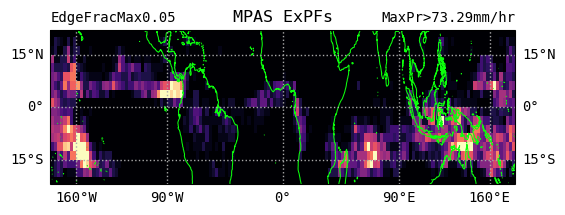

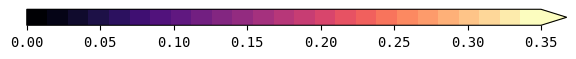

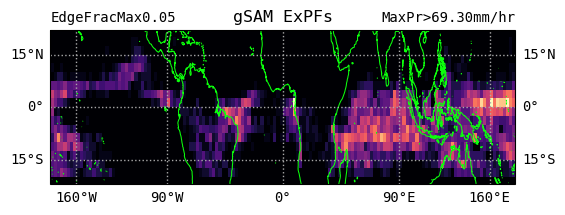

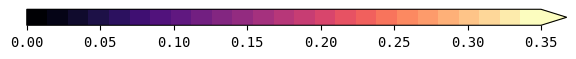

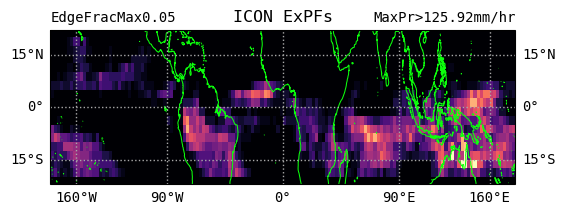

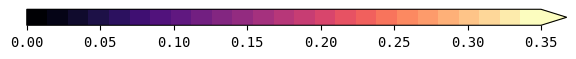

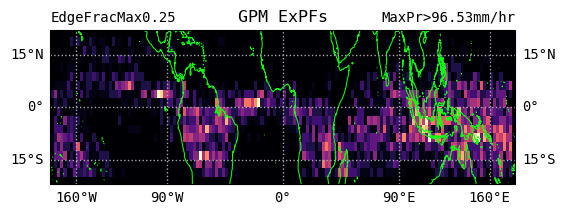

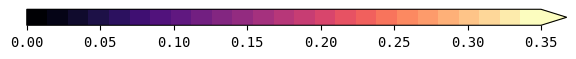

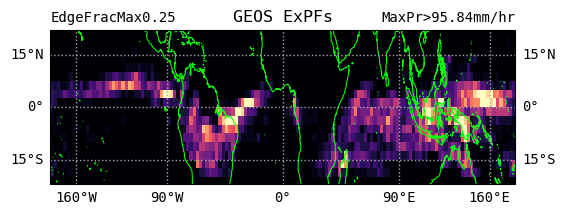

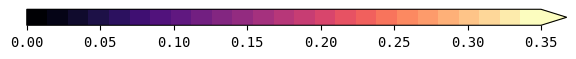

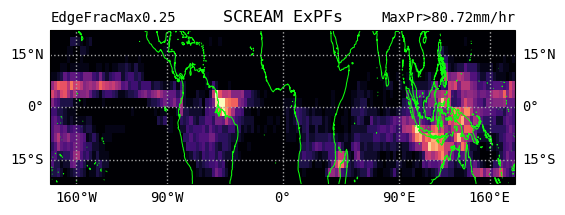

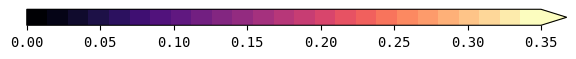

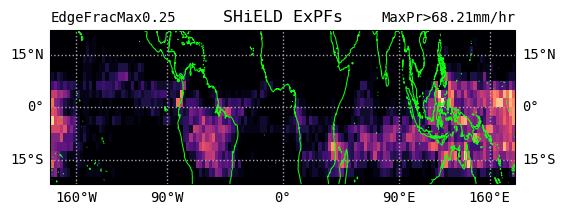

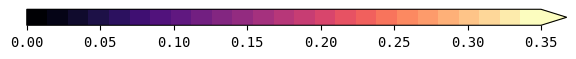

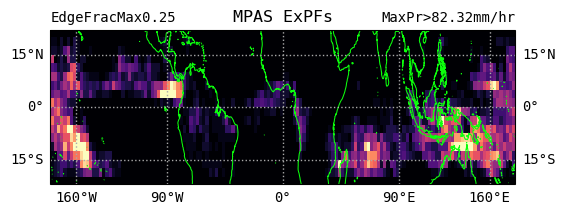

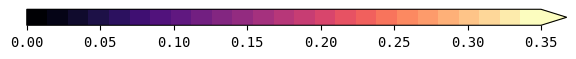

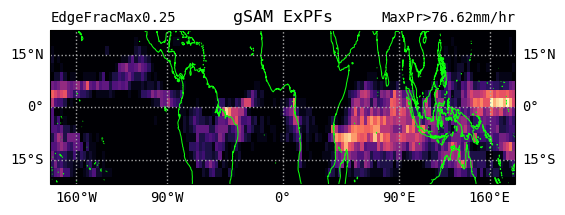

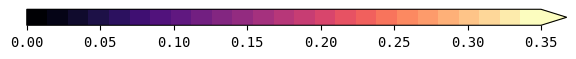

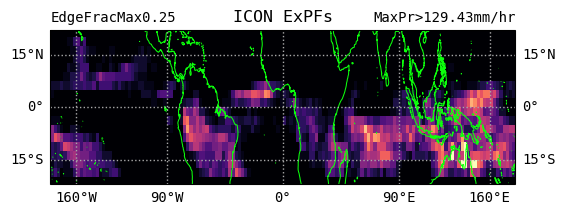

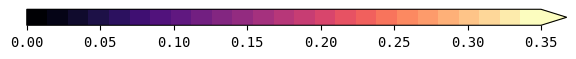

In [4]:
_RES = "0p05"
_ACCUM = "15min"
edge_frac_max_list = [0.0, 0.05, 0.25]

for _EDGE_FRAC_MAX in edge_frac_max_list:
    # Load features (IMERG is native 0.1 deg, so it takes no res argument)
    _MAX_PR_MIN = 10.0
    feature_stats_dict = {
        'GPM': load_gpm_feature_stats(threshold=1.0, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        # 'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'GEOS': load_dyamond_feature_stats('GEOS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SCREAM': load_dyamond_feature_stats('SCREAM-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'SHiELD': load_dyamond_feature_stats('SHiELD-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'MPAS': load_dyamond_feature_stats('MPAS-3km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'gSAM': load_dyamond_feature_stats('gSAM-4km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
        'ICON': load_dyamond_feature_stats('ICON-SAP-5km', accum=_ACCUM, res=_RES, edge_frac_max=_EDGE_FRAC_MAX, maxpr_min=_MAX_PR_MIN),
    }

    for source, df in feature_stats_dict.items():
        thresh = df['max_precip_mm_hr'].quantile(0.95)
        df = df.filter(
            pl.col("max_precip_mm_hr") >= thresh
        )
        fig, ax, cbar_fig, cbar_ax, data = _make_map(
            df,
            normalize=True,
            cmap=discrete_cmap('magma', N=25, under_color='White'),
            norm=colors.Normalize(vmin=0.0, vmax=0.35),
            coastline_color='xkcd:neon green',
            ticks=[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
            return_colorbar_separate=True,
            figsize=(6,2)
        )
        ax.set_title(f'{source} ExPFs', fontsize=12)
        ax.set_title(f'MaxPr>{thresh:.2f}mm/hr', loc='right', fontsize=10)
        ax.set_title(f'EdgeFracMax{_EDGE_FRAC_MAX}', loc='left', fontsize=10)
        save_figure(fig, f'MapExPFs_{source}_EdgeFracMax{_EDGE_FRAC_MAX}.pdf')
        save_figure(cbar_fig, f'MapExPFs_{source}_EdgeFracMax{_EDGE_FRAC_MAX}_colorbar.pdf')